# NB11 — Fusión con densidad mamaria sobre las mejores configuraciones del NB09

## Propósito

Replicar el experimento de fusión con densidad del Hito 2 (NB07) sobre los **tres mejores candidatos** del NB09 (a nivel estudio, agregando con `max(pred_L, pred_R)`):

1. **M_A_22 + xgb** — mejor AUC global a nivel estudio agregado (0.6891)
2. **M_A_gg + mlp** — equivalente directo al campeón del Hito 2 (mismo pool, misma cabeza)
3. **M_A_22 + rf** — mejor calibrado (Brier=0.041, ECE=0.011)

Para cada candidato evaluamos **tres modelos de fusión** (LogReg, HistGB, MLP) que combinan la probabilidad agregada del estudio con la densidad mamaria (codificada como one-hot de 4 niveles).

## Pregunta de investigación

¿La fusión tardía con densidad sobre las mejores configuraciones del NB09 supera el AUC=0.7067 del `M_A_mlp_dens` del Hito 2?

## Salidas

- `Outputs/Predicciones_v2/fusion_resultados.csv` — tabla maestra con AUC base, fusión por modelo, deltas y p-valores DeLong.
- `Outputs/Predicciones_v2/fusion_densidad/{candidato}__{fusion_model}_test.npy` — predicciones de fusión guardadas para uso posterior.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve

# Raíz del proyecto: por defecto, la carpeta padre de notebooks/.
# Sobrescribible con la variable de entorno TFM_PROJECT_ROOT.
BASE      = os.environ.get('TFM_PROJECT_ROOT',
                           os.path.abspath(os.path.join(os.getcwd(), '..')))
OUTPUTS      = os.path.join(BASE, 'outputs')
FEATURES_DIR = os.path.join(OUTPUTS, 'Features')
PRED_DIR_V2  = os.path.join(OUTPUTS, 'Predicciones_v2')
PRED_DIR_V1  = os.path.join(OUTPUTS, 'Predicciones')
FUSION_DIR   = os.path.join(PRED_DIR_V2, 'fusion_densidad')
NB_DIR    = os.path.join(BASE, 'src')

os.makedirs(FUSION_DIR, exist_ok=True)
sys.path.insert(0, NB_DIR)
from tfm_eval import (  # noqa: E402
    bootstrap_metric_ci, ece_score, delong_test,
    aggregate_breast_to_study, compute_full_metrics, SEED,
)

np.random.seed(SEED)
print(f'FUSION_DIR: {FUSION_DIR}')

FUSION_DIR: c:\Users\victo\Documents\TFM\Proyecto\outputs\Predicciones_v2\fusion_densidad


## 1. Cargar metadata, etiquetas y densidad

Mismas estructuras que en NB09/NB10. La densidad la codificamos como **one-hot de 4 columnas** (A, B, C, D) para no asumir relación lineal entre las categorías y para que cualquier modelo de fusión la trate por igual.

In [2]:
meta = pd.read_csv(os.path.join(FEATURES_DIR, 'metadata.csv'))
N = len(meta)

# Nivel estudio
y_E = meta['y_estudio'].values.astype(int)
is_train_E = (meta['split'].values == 'training')
is_test_E  = (meta['split'].values == 'test')
density_E  = meta['density'].values
study_ids_E = meta['study_id'].values

y_E_train = y_E[is_train_E]
y_E_test  = y_E[is_test_E]
density_E_train = density_E[is_train_E]
density_E_test  = density_E[is_test_E]

# Verificar valores únicos y NaN en densidad
print(f'Densidad train — únicos: {pd.Series(density_E_train).value_counts(dropna=False).to_dict()}')
print(f'Densidad test  — únicos: {pd.Series(density_E_test).value_counts(dropna=False).to_dict()}')

# One-hot codificación (asegurando 4 columnas A/B/C/D incluso si alguna no aparece)
def one_hot_density(d):
    df = pd.get_dummies(pd.Series(d), prefix='dens')
    for c in ['dens_A', 'dens_B', 'dens_C', 'dens_D']:
        if c not in df.columns:
            df[c] = 0
    return df[['dens_A', 'dens_B', 'dens_C', 'dens_D']].values.astype(np.float32)

D_train = one_hot_density(density_E_train)
D_test  = one_hot_density(density_E_test)
print(f'\nOne-hot density: train={D_train.shape}  test={D_test.shape}')
print(f'Distribución (train): A={D_train[:,0].sum():.0f}  B={D_train[:,1].sum():.0f}  C={D_train[:,2].sum():.0f}  D={D_train[:,3].sum():.0f}')

Densidad train — únicos: {'C': 3055, 'D': 535, 'B': 389, 'A': 20}
Densidad test  — únicos: {'C': 764, 'D': 134, 'B': 96, 'A': 6}

One-hot density: train=(3999, 4)  test=(1000, 4)
Distribución (train): A=20  B=389  C=3055  D=535


## 2. Cargar y agregar predicciones de los 3 candidatos

Cada candidato es un modelo entrenado a nivel mama en el NB09. Cargamos sus OOF y test (a nivel mama, 7998 y 2000 entradas respectivamente), y los agregamos a nivel estudio con `max(L, R)` → 3999 OOF y 1000 test.

In [3]:
study_ids_E_train = study_ids_E[is_train_E]
study_ids_E_test  = study_ids_E[is_test_E]

CANDIDATOS = [
    ('M_A_22', 'xgb'),   # mejor AUC a nivel estudio agregado
    ('M_A_gg', 'mlp'),   # campeón a nivel mama, equivalente directo a Hito 2
    ('M_A_22', 'rf'),    # mejor calibración
]

def load_and_aggregate(config, head):
    """Carga predicciones a nivel mama y agrega a estudio con max(L, R).
    Devuelve (pred_E_oof, pred_E_test)."""
    pred_M_oof  = np.load(os.path.join(PRED_DIR_V2, f'{config}__{head}_oof.npy'))
    pred_M_test = np.load(os.path.join(PRED_DIR_V2, f'{config}__{head}_test.npy'))
    pred_E_oof,  _ = aggregate_breast_to_study(pred_M_oof,  study_ids_E_train, agg='max')
    pred_E_test, _ = aggregate_breast_to_study(pred_M_test, study_ids_E_test,  agg='max')
    return pred_E_oof, pred_E_test

# Cargar todos los candidatos
base_preds = {}
for cfg, head in CANDIDATOS:
    key = f'{cfg}__{head}'
    pred_oof, pred_test = load_and_aggregate(cfg, head)
    auc_test_base = roc_auc_score(y_E_test, pred_test)
    base_preds[key] = {'oof': pred_oof, 'test': pred_test, 'auc_test_base': auc_test_base}
    print(f'{key:18s}  OOF shape={pred_oof.shape}  test shape={pred_test.shape}  AUC_test_base={auc_test_base:.4f}')

M_A_22__xgb         OOF shape=(3999,)  test shape=(1000,)  AUC_test_base=0.6891
M_A_gg__mlp         OOF shape=(3999,)  test shape=(1000,)  AUC_test_base=0.6553
M_A_22__rf          OOF shape=(3999,)  test shape=(1000,)  AUC_test_base=0.6679


## 3. Baselines: solo densidad y solo modelo base

Antes de la fusión, dos baselines de referencia.

In [4]:
# Baseline 1: usar la densidad directamente como predictor ordinal (A=0, B=1, C=2, D=3)
dens_ord_train = np.array([{'A':0,'B':1,'C':2,'D':3}.get(d, -1) for d in density_E_train])
dens_ord_test  = np.array([{'A':0,'B':1,'C':2,'D':3}.get(d, -1) for d in density_E_test])

auc_dens_solo = roc_auc_score(y_E_test, dens_ord_test)
print(f'Baseline 1: solo densidad (ordinal)  AUC = {auc_dens_solo:.4f}')
print('  (recordatorio: en VinDr-Mammo densidad anti-correlaciona ligeramente con suspicious; un AUC <0.5 invertiría el signo)')

# Probar también con dirección invertida (1-x)
auc_dens_inv = roc_auc_score(y_E_test, -dens_ord_test)
print(f'Baseline 1b: densidad invertida       AUC = {auc_dens_inv:.4f}')

print('\nBaseline 2: AUC del modelo base por candidato (sin densidad):')
for key, d in base_preds.items():
    print(f'  {key:18s}  AUC = {d["auc_test_base"]:.4f}')

Baseline 1: solo densidad (ordinal)  AUC = 0.4487
  (recordatorio: en VinDr-Mammo densidad anti-correlaciona ligeramente con suspicious; un AUC <0.5 invertiría el signo)
Baseline 1b: densidad invertida       AUC = 0.5513

Baseline 2: AUC del modelo base por candidato (sin densidad):
  M_A_22__xgb         AUC = 0.6891
  M_A_gg__mlp         AUC = 0.6553
  M_A_22__rf          AUC = 0.6679


## 4. Modelos de fusión

Para cada candidato base, entrenamos tres modelos de fusión sobre `[pred_E_oof, D_train_one_hot]` (5 features) → predicen sobre `[pred_E_test, D_test_one_hot]`.

- **LogReg fusión**: regresión logística con `class_weight='balanced'`, regularización L2 (C=1.0).
- **HistGB fusión**: gradient boosting de árboles, capacidad limitada (max_leaf_nodes=15, max_iter=200).
- **MLP fusión**: red pequeña (1 capa de 16 neuronas), entrenada con sklearn.

Todos los modelos usan StandardScaler. Los hiperparámetros son fijos (no hay grid search): con 5 features y ~4000 muestras, modelos sencillos con valores razonables son suficientes.

In [5]:
def build_fusion_features(pred_E, D):
    """Construye [pred_E, dens_A, dens_B, dens_C, dens_D] como features."""
    return np.column_stack([pred_E.reshape(-1, 1), D]).astype(np.float32)

def fit_predict_fusion(pred_E_oof, pred_E_test, D_train, D_test, y_train, model_name):
    """Entrena un modelo de fusión y devuelve probabilidades sobre test."""
    X_train = build_fusion_features(pred_E_oof, D_train)
    X_test  = build_fusion_features(pred_E_test, D_test)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    
    if model_name == 'logreg':
        clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
                                  random_state=SEED, solver='lbfgs')
    elif model_name == 'histgb':
        clf = HistGradientBoostingClassifier(max_leaf_nodes=15, learning_rate=0.05,
                                             max_iter=200, class_weight='balanced',
                                             random_state=SEED)
    elif model_name == 'mlp':
        clf = MLPClassifier(hidden_layer_sizes=(16,), max_iter=500, random_state=SEED,
                            learning_rate_init=0.01, early_stopping=True, validation_fraction=0.15)
    else:
        raise ValueError(f'modelo {model_name} desconocido')
    
    clf.fit(X_train_s, y_train)
    return clf.predict_proba(X_test_s)[:, 1]

FUSION_MODELS = ['logreg', 'histgb', 'mlp']

fusion_preds = {}  # {key_cand_fmodel: array(test)}
for key, d in base_preds.items():
    for fm in FUSION_MODELS:
        pred_fusion = fit_predict_fusion(
            d['oof'], d['test'], D_train, D_test, y_E_train, fm
        )
        fusion_preds[f'{key}__fuse_{fm}'] = pred_fusion
        # Guardar para uso posterior
        cfg_str = key.replace('__', '_')
        np.save(os.path.join(FUSION_DIR, f'{cfg_str}__fuse_{fm}_test.npy'), pred_fusion)

print(f'Modelos de fusión entrenados: {len(fusion_preds)} ({len(CANDIDATOS)} candidatos × {len(FUSION_MODELS)} modelos)')

Modelos de fusión entrenados: 9 (3 candidatos × 3 modelos)


## 5. Tabla maestra de resultados

Para cada combinación (candidato × modelo fusión), calculamos métricas completas y test DeLong contra el modelo base.

In [6]:
rows = []
for cfg, head in CANDIDATOS:
    key = f'{cfg}__{head}'
    base_pred = base_preds[key]['test']
    
    # Métricas del base
    m_base = compute_full_metrics(y_E_test, base_pred, n_boot=1000)
    rows.append({
        'candidato': key, 'modelo_fusion': 'NINGUNO_base',
        **m_base, 'delta_vs_base': 0.0, 'p_delong_vs_base': np.nan,
    })
    
    # Métricas de cada fusión
    for fm in FUSION_MODELS:
        fkey = f'{key}__fuse_{fm}'
        pred_fusion = fusion_preds[fkey]
        m_fusion = compute_full_metrics(y_E_test, pred_fusion, n_boot=1000)
        delong_res = delong_test(y_E_test, pred_fusion, base_pred)
        rows.append({
            'candidato': key, 'modelo_fusion': fm,
            **m_fusion,
            'delta_vs_base': delong_res['delta'],
            'p_delong_vs_base': delong_res['p_value'],
        })

df_fusion = pd.DataFrame(rows)
df_fusion.to_csv(os.path.join(PRED_DIR_V2, 'fusion_resultados.csv'), index=False)

# Mostrar tabla
print('=' * 110)
print(f'{"Candidato":<20s} {"Fusión":<14s} {"AUC [IC95%]":<24s} {"Brier":<8s} {"ECE":<8s} {"Δ vs base":<12s} {"p_DeLong":<10s}')
print('=' * 110)
for _, r in df_fusion.iterrows():
    delta_str = f'{r["delta_vs_base"]:+.4f}' if r['modelo_fusion'] != 'NINGUNO_base' else '   -    '
    p_str = f'{r["p_delong_vs_base"]:.4f}' if not np.isnan(r['p_delong_vs_base']) else '   -    '
    sig = '★' if (not np.isnan(r['p_delong_vs_base']) and r['p_delong_vs_base'] < 0.05) else ' '
    print(f'  {sig}{r["candidato"]:<19s} {r["modelo_fusion"]:<14s} '
          f'{r["auc"]:.4f} [{r["auc_lo"]:.4f},{r["auc_hi"]:.4f}]  '
          f'{r["brier"]:.4f}  {r["ece"]:.4f}  {delta_str:<12s} {p_str}')

Candidato            Fusión         AUC [IC95%]              Brier    ECE      Δ vs base    p_DeLong  
   M_A_22__xgb         NINGUNO_base   0.6891 [0.6282,0.7479]  0.1403  0.2599     -            -    
   M_A_22__xgb         logreg         0.6836 [0.6266,0.7409]  0.2182  0.3787  -0.0055      0.7590
  ★M_A_22__xgb         histgb         0.5804 [0.5136,0.6504]  0.1744  0.2699  -0.1087      0.0015
   M_A_22__xgb         mlp            0.6356 [0.5738,0.7009]  0.0760  0.0248  -0.0536      0.1208
   M_A_gg__mlp         NINGUNO_base   0.6553 [0.5917,0.7190]  0.2180  0.3704     -            -    
   M_A_gg__mlp         logreg         0.6728 [0.6122,0.7329]  0.2084  0.3565  +0.0175      0.1103
   M_A_gg__mlp         histgb         0.6168 [0.5485,0.6839]  0.1912  0.2967  -0.0385      0.1512
   M_A_gg__mlp         mlp            0.6682 [0.6077,0.7283]  0.0792  0.0277  +0.0129      0.2403
   M_A_22__rf          NINGUNO_base   0.6679 [0.6095,0.7276]  0.0756  0.0367     -            -    
   M_A_22

## 6. Comparación contra Hito 2 (M_A_mlp_dens = 0.7067)

La pregunta clave: ¿la mejor fusión del NB11 supera el AUC del modelo con densidad del Hito 2?

In [7]:
# Cargar predicción del Hito 2 con densidad (originalmente a nivel mama) y agregar a estudio
try:
    pred_hito2_M = np.load(os.path.join(PRED_DIR_V1, 'M_A_mlp_dens_test.npy'))
    
    if len(pred_hito2_M) == 2000:
        # Sanity check: validar el AUC original a nivel mama (debería ser 0.7067)
        y_M_test_check = np.concatenate([
            meta['y_L'].values[is_test_E], meta['y_R'].values[is_test_E]
        ]).astype(int)
        auc_hito2_M = roc_auc_score(y_M_test_check, pred_hito2_M)
        # Agregar a nivel estudio con max(L, R) — misma operación que aplicamos al NB11
        pred_hito2_mladens, _ = aggregate_breast_to_study(pred_hito2_M, study_ids_E_test, agg='max')
        print(f'Hito 2 M_A_mlp_dens AUC (nivel mama, original):           {auc_hito2_M:.4f}')
    else:
        # Ya está a nivel estudio (caso defensivo, no debería ocurrir)
        pred_hito2_mladens = pred_hito2_M
        print(f'Hito 2 M_A_mlp_dens ya está a nivel estudio ({len(pred_hito2_M)} preds).')
    
    auc_hito2 = roc_auc_score(y_E_test, pred_hito2_mladens)
    print(f'Hito 2 M_A_mlp_dens AUC (nivel estudio, agregado con max): {auc_hito2:.4f}')
    print(f'                              ← ESTA es la referencia para comparación equitativa con NB11')
    print()
    
    # Comparar cada fusión NB11 contra Hito 2 agregado
    print('=' * 100)
    print(f'{"Candidato":<22s} {"Fusión":<10s} {"AUC NB11":<10s} {"AUC H2":<10s} {"Δ":<10s} {"p_DeLong":<10s}')
    print('=' * 100)
    h2_vs_nb11_rows = []
    for cfg, head in CANDIDATOS:
        key = f'{cfg}__{head}'
        for fm in FUSION_MODELS:
            pred_nb11 = fusion_preds[f'{key}__fuse_{fm}']
            res = delong_test(y_E_test, pred_nb11, pred_hito2_mladens)
            h2_vs_nb11_rows.append({
                'candidato': key, 'modelo_fusion': fm,
                'auc_nb11': res['auc_a'], 'auc_hito2_agg': res['auc_b'],
                'delta_nb11_minus_h2': res['delta'],
                'p_delong': res['p_value'],
            })
            sig = '★' if res['p_value'] < 0.05 else ' '
            print(f'  {sig}{key:<21s} {fm:<10s} {res["auc_a"]:.4f}    {res["auc_b"]:.4f}    '
                  f'{res["delta"]:+.4f}   {res["p_value"]:.4f}')
    df_h2 = pd.DataFrame(h2_vs_nb11_rows)
    df_h2.to_csv(os.path.join(PRED_DIR_V2, 'fusion_vs_hito2.csv'), index=False)
except FileNotFoundError as e:
    print(f'No se pudo cargar Hito 2: {e}')
    auc_hito2 = None
    pred_hito2_mladens = None

Hito 2 M_A_mlp_dens AUC (nivel mama, original):           0.7067
Hito 2 M_A_mlp_dens AUC (nivel estudio, agregado con max): 0.6783
                              ← ESTA es la referencia para comparación equitativa con NB11

Candidato              Fusión     AUC NB11   AUC H2     Δ          p_DeLong  
   M_A_22__xgb           logreg     0.6836    0.6783    +0.0054   0.8367
  ★M_A_22__xgb           histgb     0.5804    0.6783    -0.0979   0.0038
   M_A_22__xgb           mlp        0.6356    0.6783    -0.0427   0.1957
   M_A_gg__mlp           logreg     0.6728    0.6783    -0.0055   0.7688
  ★M_A_gg__mlp           histgb     0.6168    0.6783    -0.0614   0.0395
   M_A_gg__mlp           mlp        0.6682    0.6783    -0.0101   0.5965
   M_A_22__rf            logreg     0.6691    0.6783    -0.0092   0.7367
   M_A_22__rf            histgb     0.6412    0.6783    -0.0371   0.2354
   M_A_22__rf            mlp        0.6641    0.6783    -0.0141   0.6082


## 7. Análisis estratificado por densidad — antes vs después de la fusión

Comparamos el AUC por estrato de densidad antes y después de la fusión, para la mejor combinación. Pregunta: **¿la fusión beneficia uniformemente a todos los estratos, o ayuda más a algunos?**

In [8]:
# Identificar la mejor fusión por AUC
best_row = df_fusion[df_fusion['modelo_fusion'] != 'NINGUNO_base'].nlargest(1, 'auc').iloc[0]
best_key = best_row['candidato']
best_fm  = best_row['modelo_fusion']
print(f'Mejor combinación de fusión: {best_key}  +  {best_fm}  (AUC test = {best_row["auc"]:.4f})')
print()

pred_base   = base_preds[best_key]['test']
pred_fusion = fusion_preds[f'{best_key}__fuse_{best_fm}']

print('Estratificación por densidad (test):')
print(f'{"Densidad":<10s} {"n":<6s} {"n_pos":<7s} {"AUC base":<22s} {"AUC fusión":<22s} {"Δ":<8s}')
for d in ['A', 'B', 'C', 'D']:
    mask = density_E_test == d
    n = int(mask.sum()); n_pos = int(y_E_test[mask].sum())
    if n_pos < 3 or (n - n_pos) < 3:
        print(f'  {d:<8s}  {n:<6d} {n_pos:<7d} (insuficiente)')
        continue
    auc_b, lo_b, hi_b = bootstrap_metric_ci(y_E_test[mask], pred_base[mask],   roc_auc_score, n_boot=1000)
    auc_f, lo_f, hi_f = bootstrap_metric_ci(y_E_test[mask], pred_fusion[mask], roc_auc_score, n_boot=1000)
    print(f'  {d:<8s}  {n:<6d} {n_pos:<7d} '
          f'{auc_b:.4f} [{lo_b:.4f},{hi_b:.4f}]  '
          f'{auc_f:.4f} [{lo_f:.4f},{hi_f:.4f}]  '
          f'{auc_f-auc_b:+.4f}')

Mejor combinación de fusión: M_A_22__xgb  +  logreg  (AUC test = 0.6836)

Estratificación por densidad (test):
Densidad   n      n_pos   AUC base               AUC fusión             Δ       
  A         6      0       (insuficiente)
  B         96     12      0.7649 [0.6118,0.8992]  0.7649 [0.6118,0.8992]  +0.0000
  C         764    79      0.6638 [0.5914,0.7295]  0.6638 [0.5914,0.7295]  +0.0000
  D         134    5       0.6977 [0.3925,0.9975]  0.6977 [0.3925,0.9975]  +0.0000


## 8. Curvas ROC — base vs cada fusión

Comparación visual: para cada candidato, base vs sus 3 fusiones.

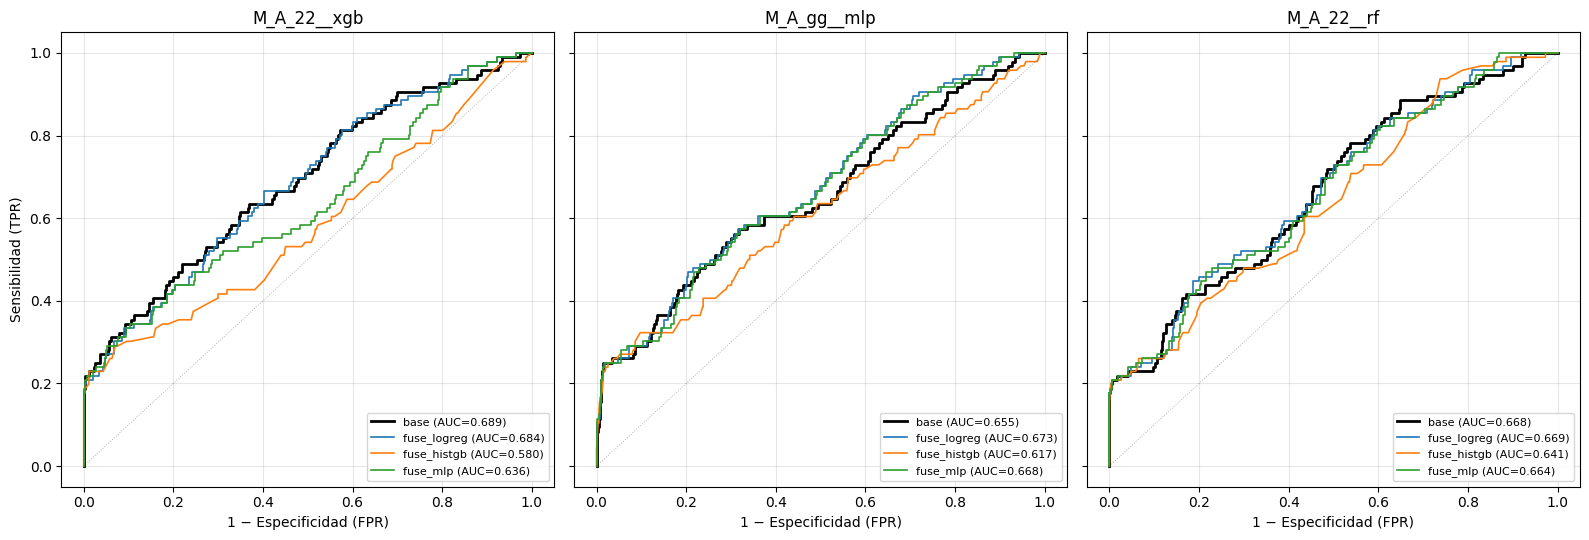

Guardado: fusion_curvas_roc.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
colors = {'base': 'black', 'logreg': '#1f77b4', 'histgb': '#ff7f0e', 'mlp': '#2ca02c'}

for ax, (cfg, head) in zip(axes, CANDIDATOS):
    key = f'{cfg}__{head}'
    # Base
    pred = base_preds[key]['test']
    fpr, tpr, _ = roc_curve(y_E_test, pred)
    auc = roc_auc_score(y_E_test, pred)
    ax.plot(fpr, tpr, label=f'base (AUC={auc:.3f})', color=colors['base'], linewidth=2)
    
    # Cada fusión
    for fm in FUSION_MODELS:
        pred_f = fusion_preds[f'{key}__fuse_{fm}']
        fpr_f, tpr_f, _ = roc_curve(y_E_test, pred_f)
        auc_f = roc_auc_score(y_E_test, pred_f)
        ax.plot(fpr_f, tpr_f, label=f'fuse_{fm} (AUC={auc_f:.3f})', color=colors[fm], linewidth=1.2)
    
    ax.plot([0, 1], [0, 1], 'k:', alpha=0.3, linewidth=0.7)
    ax.set_xlabel('1 − Especificidad (FPR)')
    ax.set_title(f'{key}')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Sensibilidad (TPR)')
plt.tight_layout()
plt.savefig(os.path.join(PRED_DIR_V2, 'fusion_curvas_roc.png'), dpi=140, bbox_inches='tight')
plt.show()
print('Guardado: fusion_curvas_roc.png')

## 9. Resumen ejecutivo

In [10]:
print('═' * 80)
print(' RESUMEN EJECUTIVO — NB11 fusión con densidad')
print('═' * 80)

print('\n1. AUC base por candidato (sin densidad):')
for cfg, head in CANDIDATOS:
    key = f'{cfg}__{head}'
    print(f'   {key:18s}  AUC = {base_preds[key]["auc_test_base"]:.4f}')

print('\n2. Mejor fusión por candidato:')
for cfg, head in CANDIDATOS:
    key = f'{cfg}__{head}'
    sub = df_fusion[(df_fusion.candidato == key) & (df_fusion.modelo_fusion != 'NINGUNO_base')]
    best = sub.nlargest(1, 'auc').iloc[0]
    base_auc = base_preds[key]['auc_test_base']
    sig = '★' if best['p_delong_vs_base'] < 0.05 else ' '
    print(f'  {sig}{key:18s}  mejor fuse={best["modelo_fusion"]:<8s}  '
          f'AUC={best["auc"]:.4f} (base={base_auc:.4f}, Δ={best["delta_vs_base"]:+.4f}, p={best["p_delong_vs_base"]:.4f})')

if auc_hito2 is not None:
    print(f'\n3. Comparación contra Hito 2 (M_A_mlp_dens AUC={auc_hito2:.4f}):')
    top5 = df_h2.nlargest(5, 'auc_nb11')
    for _, r in top5.iterrows():
        sig = '★' if r['p_delong'] < 0.05 else ' '
        print(f'  {sig}{r["candidato"]:18s} + fuse_{r["modelo_fusion"]:<8s}  '
              f'AUC={r["auc_nb11"]:.4f}  (Δ vs H2={r["delta_nb11_minus_h2"]:+.4f}, p={r["p_delong"]:.4f})')

print('\n' + '═' * 80)
print(' Archivos generados:')
print('═' * 80)
for f in ['fusion_resultados.csv', 'fusion_vs_hito2.csv', 'fusion_curvas_roc.png']:
    path = os.path.join(PRED_DIR_V2, f)
    exists = '✓' if os.path.isfile(path) else '✗'
    print(f'  {exists}  {f}')
n_fusion_files = len([f for f in os.listdir(FUSION_DIR) if f.endswith('_test.npy')])
print(f'  ✓  fusion_densidad/  ({n_fusion_files} archivos *_test.npy)')

════════════════════════════════════════════════════════════════════════════════
 RESUMEN EJECUTIVO — NB11 fusión con densidad
════════════════════════════════════════════════════════════════════════════════

1. AUC base por candidato (sin densidad):
   M_A_22__xgb         AUC = 0.6891
   M_A_gg__mlp         AUC = 0.6553
   M_A_22__rf          AUC = 0.6679

2. Mejor fusión por candidato:
   M_A_22__xgb         mejor fuse=logreg    AUC=0.6836 (base=0.6891, Δ=-0.0055, p=0.7590)
   M_A_gg__mlp         mejor fuse=logreg    AUC=0.6728 (base=0.6553, Δ=+0.0175, p=0.1103)
   M_A_22__rf          mejor fuse=logreg    AUC=0.6691 (base=0.6679, Δ=+0.0012, p=0.9264)

3. Comparación contra Hito 2 (M_A_mlp_dens AUC=0.6783):
   M_A_22__xgb        + fuse_logreg    AUC=0.6836  (Δ vs H2=+0.0054, p=0.8367)
   M_A_gg__mlp        + fuse_logreg    AUC=0.6728  (Δ vs H2=-0.0055, p=0.7688)
   M_A_22__rf         + fuse_logreg    AUC=0.6691  (Δ vs H2=-0.0092, p=0.7367)
   M_A_gg__mlp        + fuse_mlp       AUC=0.

## Siguientes pasos

- **NB12 — Calibración post-hoc** (Platt e isotónica) sobre el mejor MLP a nivel mama (`M_A_gg + mlp`) y sobre el mejor modelo de fusión del NB11. Mejora Brier y ECE sin alterar AUC, importante para uso clínico.
- Tras NB12, el experimental está completo. Se procede a la **redacción definitiva** de los capítulos 4 (Metodología), 5 (Resultados) y 6 (Conclusiones) de la memoria.